# Heart Disease Classification Project

## Predictiing Heart disease using machine learning

This notebook looks into using various Python-based machine learning and data science libraries in an attempt to build machine learning models capable of predicting whether or not someone has heart disease based on some medical attributes.

We're going to take the following approach
1. Problem Definition
2. Data
3. Evaluation
4. Features
5. Modelling
6. Experimentation

## 1. Problem Definition

> Given clinical parameters about a patient , can we predict whether or not they have heart disease?

## 2. Data

The original data came from the UCI Machine Learning Repository:https://archive.ics.uci.edu/dataset/45/heart+disease

## 3. Evaluation

> If we can reach 95% accuracy at predicting whether or not a patient has heart disease during the proof of concept , we'll pursue the project



## 4. Features
      1. (age)       
      2. (sex)       
      3. (cp)        
      4. (trestbps)  
      5. (chol)      
      6. (fbs)       
      7. (restecg)   
      8. (thalach)   
      9. (exang)     
      10. (oldpeak)   
      11. (slope)     
      12. (ca)        
      13. (thal)      
      14. (target) 


## Prepare the tools

We're going to use pandas, Matplotlib,Numpy for data analysis/manipulation.

In [36]:
#Import the tools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay

%matplotlib inline

## Load Data

In [37]:
data=pd.read_csv("heart-disease (2).csv")

## Data exploration(Exploratory data analysis or EDA)

The goal here is to find out more about the data and become a subject matter export on the dataset you are working with.

1. What question(s) are you trying to solve?
2. What kind of data do we have and how we treat different types?
3. What's missing from the data and how do you deal with it?
4. Where are the outliers and why should you care about them?'
5. How can you add , change or remove features to get out more of your data?

In [38]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [39]:
data["target"].value_counts()

target
1    165
0    138
Name: count, dtype: int64

<Axes: xlabel='target'>

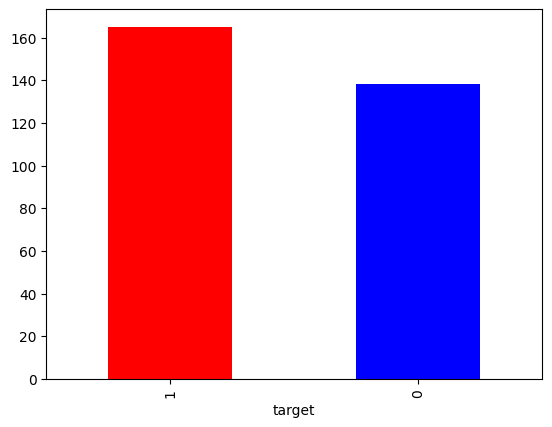

In [40]:
data["target"].value_counts().plot(kind="bar",color=["red","blue"])

In [41]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [42]:
#Are there any missing values?
data.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

### Heart Disease Frequency according to Sex

In [43]:
data["sex"].value_counts()

sex
1    207
0     96
Name: count, dtype: int64

In [44]:
#Compare target column with sex column
pd.crosstab(data["target"],data["sex"])

sex,0,1
target,,
0,24,114
1,72,93


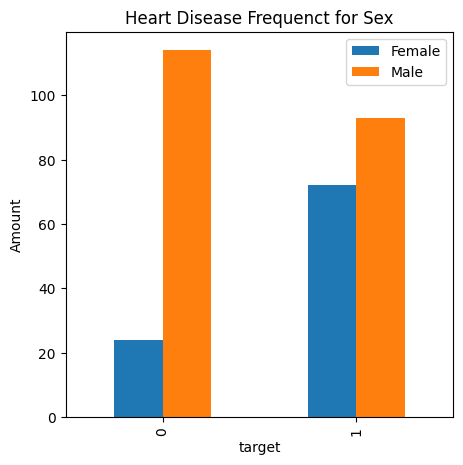

In [45]:
pd.crosstab(data["target"],data["sex"]).plot(kind="bar",
                                             figsize=(5,5))
plt.title("Heart Disease Frequenct for Sex")
plt.ylabel("Amount")
plt.legend(["Female","Male"])

### Age vs Max Heart Rate for Heart Disease`

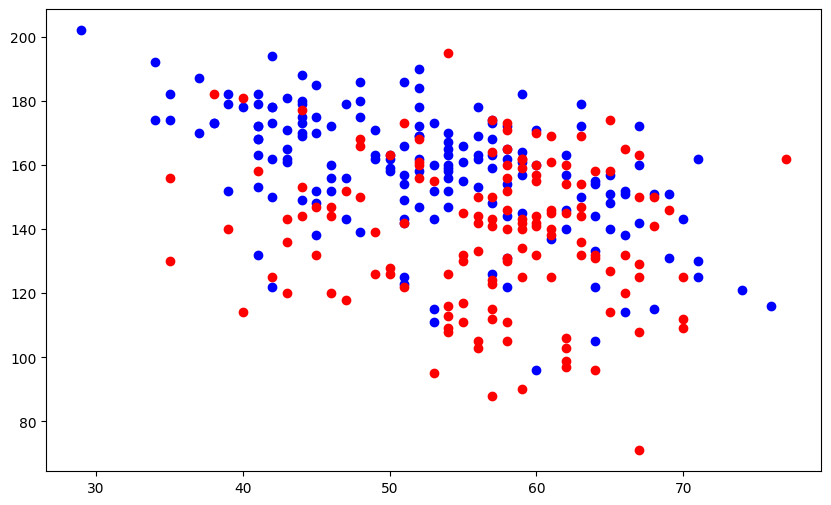

In [50]:
#Create another figure
plt.figure(figsize=(10,6))

#Scatter with positive examples
plt.scatter(data.age[data.target==1],
            data.thalach[data.target==1],
            c="blue")

plt.scatter(data.age[data.target==0],
            data.thalach[data.target==0],
            c="red")

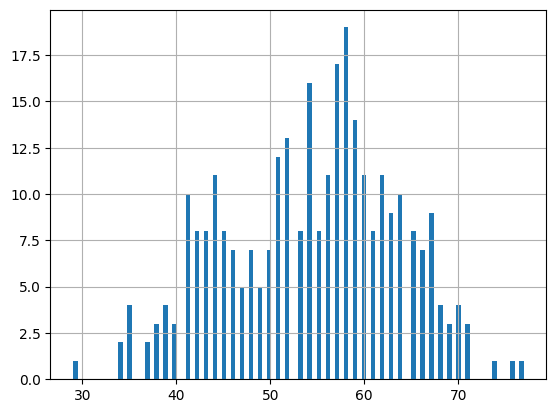

In [53]:
# Chec k the distribution of the age column with a histogram
data.age.hist(bins=100);

### Heart Disease Frequency per Chest Pain Type

In [54]:
pd.crosstab(data["cp"],data["target"])

target,0,1
cp,,
0,104,39
1,9,41
2,18,69
3,7,16


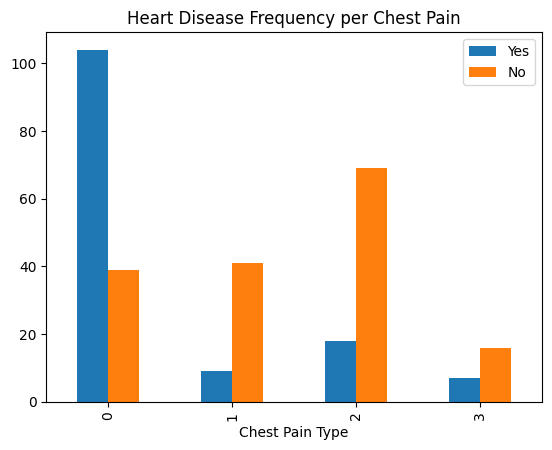

In [59]:
#Make the crosstab more visual
pd.crosstab(data["cp"],data["target"]).plot(kind="bar")
plt.legend(["Yes", "No"])
plt.title("Heart Disease Frequency per Chest Pain")
plt.xlabel("Chest Pain Type");

In [60]:
# Make a correlation matrix 
data.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


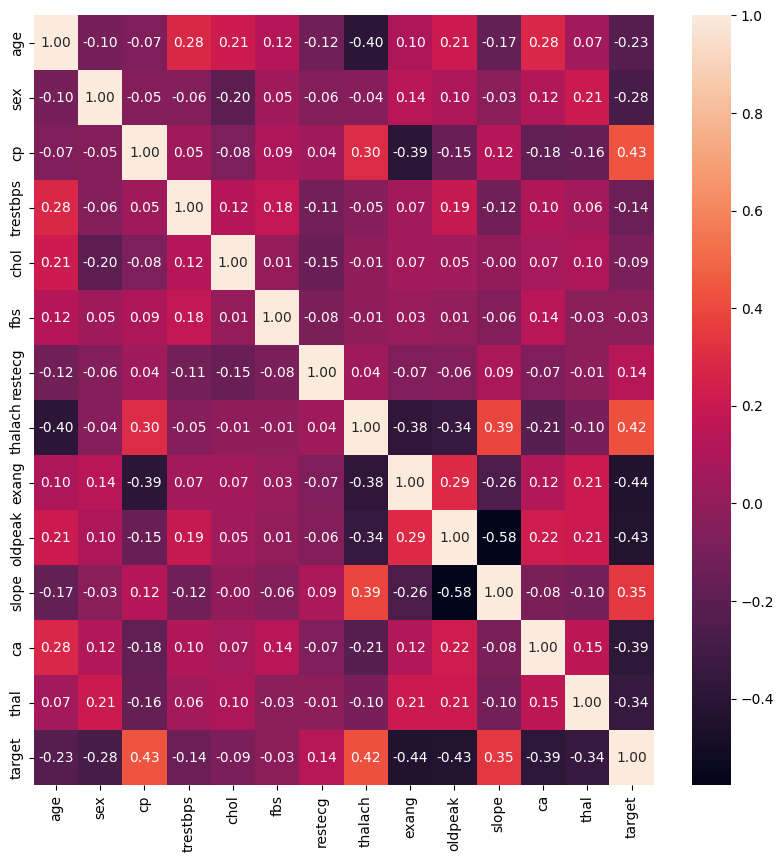

In [63]:
corr_matrix=data.corr()
fig, ax=plt.subplots(figsize=(10,10))

ax=sns.heatmap(corr_matrix,
               annot=True,
               fmt=".2f")